In [137]:
import pymor               
from pymor.basic import * 
import matplotlib.pyplot as plt

print(f"pyMOR is ready! Version: {pymor.__version__}")

pyMOR is ready! Version: 2025.1.2


In [138]:
from pymor.models.examples import heat_equation_example
fom = heat_equation_example(grid_intervals=50, nt=50)
parameter_space = fom.parameters.space(1, 101)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [139]:
print(fom.products.keys())

dict_keys(['h1', 'h1_semi', 'l2', 'h1_0', 'h1_0_semi', 'l2_0'])


In [140]:
print(fom.parameters)

{top: 1}


In [141]:
# create std snapshots (heat)
number_sample_mus = 10
sample_mus = parameter_space.sample_uniformly(number_sample_mus) # 5 mus and we compute solution for every 50 timesteps

std_snapshots = fom.solution_space.empty()
for mu in sample_mus:

    U = fom.solve(mu)
    
    std_snapshots.append(U)

len(std_snapshots), sample_mus

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

(510,
 [Mu({'top': array([1.])}),
  Mu({'top': array([12.11111111])}),
  Mu({'top': array([23.22222222])}),
  Mu({'top': array([34.33333333])}),
  Mu({'top': array([45.44444444])}),
  Mu({'top': array([56.55555556])}),
  Mu({'top': array([67.66666667])}),
  Mu({'top': array([78.77777778])}),
  Mu({'top': array([89.88888889])}),
  Mu({'top': array([101.])})])

In [142]:
# create curly U snapshots (heat)

import numpy as np

U_curly = fom.solution_space.empty()      
   
# parameters
L = len(sample_mus) - 1  # parameter steps
M = fom.time_stepper.nt # time steps
N = (L + 1)*(M + 1)  # total number elements curly_U
dt = fom.T / M    # distant one time step
d_alpha = sample_mus[1]['top'] - sample_mus[0]['top'] # distant between first and second parameter

all_solutions = [fom.solve(mu) for mu in sample_mus]  # compute FOM solutions for all mu

for l in range(L + 1):
        
    vector = all_solutions[l][0].copy() # copy keeps all_solutions as it was
    vector *= np.sqrt(N) 
    U_curly.append(vector) # here we add starting values for every mu: u_h^{\alpha_l}(t_0^l) 

for j in range(1, M + 1):

    diff_t = (all_solutions[0][j] - all_solutions[0][j-1]) * (1.0 / dt)  
    diff_t *= np.sqrt(L + 1)
    U_curly.append(diff_t)  # D^t u_h^{\alpha_0}(t_j^0)

for l in range(1, L + 1):
    for j in range(1, M + 1):
            
        # (u_h^l(t_j^l) - u_h^{l-1}(t_j^{l-1})) over (\Delta \alpha)
        u_alpha_diff_j = (all_solutions[l][j] - all_solutions[l-1][j]) * (1.0 / d_alpha)  
        
        # (u_h^l(t_{j-1}^l) - u_h^{l-1}(t_{j-1}^{l-1})) over (\Delta \alpha)
        u_alpha_diff_j_minus_1 = (all_solutions[l][j-1] - all_solutions[l-1][j-1]) * (1.0 / d_alpha) 
        
        mixed_diff = (u_alpha_diff_j - u_alpha_diff_j_minus_1) * (1.0 / dt)  # take D^t
        U_curly.append(mixed_diff)  # here we add all other differences to U_curly

len(U_curly), N, M, dt, d_alpha

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

(510, 510, 50, 0.02, array([11.11111111]))

In [143]:
# just plot one solution of fom to check
U = fom.solve(50.0)
fom.visualize(U);

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [144]:
# POD with U_curly 
r_curly_U = 50

from pymor.algorithms.pod import pod
U_pod_basis, U_pod_singular_values = pod(U_curly,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_curly_U
                                    )
len(U_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

31

In [145]:
# POD with std 
r_std = 50

from pymor.algorithms.pod import pod
std_pod_basis, std_pod_singular_values = pod(std_snapshots,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std  
                                    )
len(std_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

40

In [146]:
print(f"Anzahl der Snapshots: {len(std_snapshots)}")
print(f"Anzahl der POD-Modi_std: {len(std_pod_basis)}")
print(f"Anzahl der POD-Modi_U: {len(U_pod_basis)}")

Anzahl der Snapshots: 510
Anzahl der POD-Modi_std: 40
Anzahl der POD-Modi_U: 31


In [147]:
# construct ROM using curly U 

from pymor.reductors.parabolic import ParabolicRBReductor

reductor_U = ParabolicRBReductor(
       fom=fom,
       RB=U_pod_basis,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=None,
       check_tol=None
   )
rom_U = reductor_U.reduce()

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [148]:
# construct ROM using std 

from pymor.reductors.parabolic import ParabolicRBReductor

reductor_std = ParabolicRBReductor(
       fom=fom,
       RB=std_pod_basis,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=None,
       check_tol=None
   )
rom_std = reductor_std.reduce()

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [149]:
# # compute both ROMs for different parameters and compute errors (max over time) (here everything goes for fixed r)
# # (unterschied zu unten: kein loop über r)
# test_samples = parameter_space.sample_uniformly(1)

# errors_std = []
# errors_U = []

# for mu in test_samples:
    
#     u_fom = fom.solve(mu)  # compute fom solution
    
#     u_rom_std = rom_std.solve(mu)
#     u_rec_std = reductor_std.reconstruct(u_rom_std)   # compute std ROM solution
    
#     u_rom_U = rom_U.solve(mu)
#     u_rec_U = reductor_U.reconstruct(u_rom_U)   # compute curly U ROM solution

    
#     err_std = (u_fom - u_rec_std).norm(fom.h1_0_semi_product)  # \norm{(u_h - u_r^std)} over all time steps
#     err_U = (u_fom - u_rec_U).norm(fom.h1_0_semi_product)      # \norm{(u_h - u_r^U)} over all time steps

#     max_err_over_time_std = np.max(err_std)                  # max_{t} \norm{(u_h - u_r^std)} over all time steps
#     max_err_over_time_U = np.max(err_U)                    # max_{t} \norm{(u_h - u_r^U)} over all time steps

#     min_err_over_time_std = np.min(err_std)                  # max_{t} \norm{(u_h - u_r^std)} over all time steps
#     min_err_over_time_U = np.min(err_U)                    # max_{t} \norm{(u_h - u_r^U)} over all time steps
    
#     errors_std.append(max_err_over_time_std)  
#     errors_U.append(max_err_over_time_U)    
    
#     #print(mu)
#     print(max_err_over_time_std)
#     print(max_err_over_time_U)

In [150]:
# compute both ROMs for one test parameter and compute errors (here everything goes for fixed r)
# (unterschied zu unten: kein loop über r, kein loop über parameter, kein max über time)

r= 10

test_mu=80

# compute fom solution
u_fom_test1 = fom.solve(test_mu)

#compute std ROM solution
rom_std_r = reductor_std.reduce(dims={'RB': 10})   # create r-dim rom
u_rom_std = rom_std_r.solve(test_mu) # solve rom for this mu in low dim
u_rec_std = reductor_std.reconstruct(u_rom_std) # back to high dim

# compute U ROM solution
rom_U_r = reductor_U.reduce(dims={'RB': 10})
u_rom_U = rom_U_r.solve(test_mu) # solve rom for this mu in low dim
u_rec_U = reductor_U.reconstruct(u_rom_U) # back to high dim

# compute both ROM errors
error_rom_U = (u_fom_test1 - u_rec_U).norm(fom.products['h1_0_semi'])  # (Pr(u_h) - u_r)
error_rom_std = (u_fom_test1 - u_rec_std).norm(fom.products['h1_0_semi'])  # (Pr(u_h) - u_r)

# for the error anylysis: (u_h - u_r) = (u_h - Pr(u_h)) + (Pr(u_h) - u_r))
# compute Pr(u_h), the projection of the FOM solution onto pod_basis (with r modes)

# for U
coeffs_U = fom.products['h1_0_semi'].apply2(U_pod_basis[:r], u_fom_test1) 
u_projected_U = U_pod_basis[:r].lincomb(coeffs_U)                       # proj onto U ROM
error_proj_U = (u_fom_test1 - u_projected_U).norm(fom.products['h1_0_semi']) # (u_h - Pr(u_h))

# for std
coeffs_std = fom.products['h1_0_semi'].apply2(std_pod_basis[:r], u_fom_test1) 
u_projected_std = std_pod_basis[:r].lincomb(coeffs_std)              # proj onto std ROM
error_proj_std = (u_fom_test1 - u_projected_std).norm(fom.products['h1_0_semi']) # (u_h - Pr(u_h)) max over time


# # for error analysis we also wanna set the eigenvalue tail

# # std case
# energies_std = std_pod_singular_values**2

# total_energy = np.sum(energies_std)           # the whole sum
# captured_energy = np.sum(energies_std[:r_std])  # sum from r-th summand
# captured_energy, total_energy


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

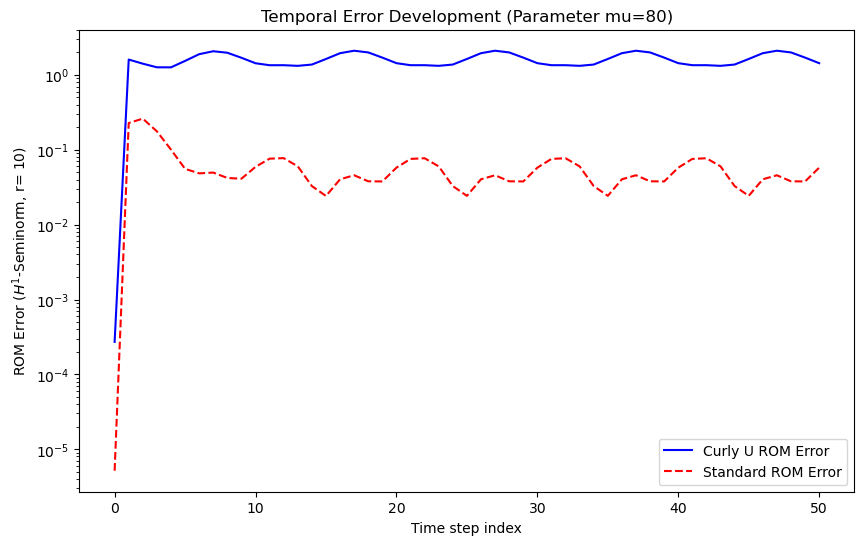

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogy(error_rom_U, 'b-', label='Curly U ROM Error')
plt.semilogy(error_rom_std, 'r--', label='Standard ROM Error')
plt.xlabel('Time step index')
plt.ylabel(r'ROM Error ($H^1$-Seminorm, r= 10)')
plt.title(f'Temporal Error Development (Parameter mu={test_mu})')
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# for one parameter
# POD basis with r modes (r fixed)
# H01 seminorm, for all time steps

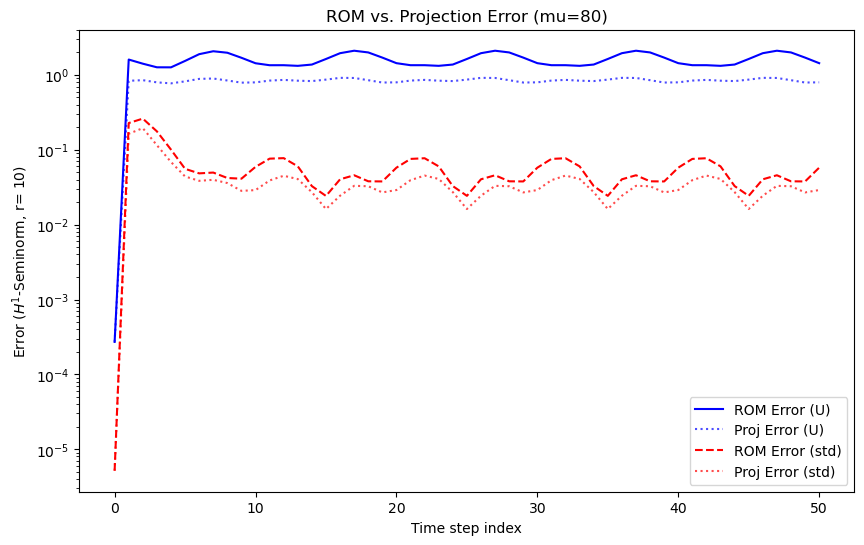

In [152]:
# hier nochmal inklusive projektionsfehler
# immernoch 1 parameter, r fixed


plt.figure(figsize=(10, 6))
plt.semilogy(error_rom_U, 'b-', label='ROM Error (U)')
plt.semilogy(error_proj_U, 'b:', alpha=0.7, label='Proj Error (U)')
plt.semilogy(error_rom_std, 'r--', label='ROM Error (std)')
plt.semilogy(error_proj_std, 'r:', alpha=0.7, label='Proj Error (std)')
plt.xlabel('Time step index')
plt.ylabel(r'Error ($H^1$-Seminorm, r= 10)')
plt.title(f'ROM vs. Projection Error (mu={test_mu})')
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

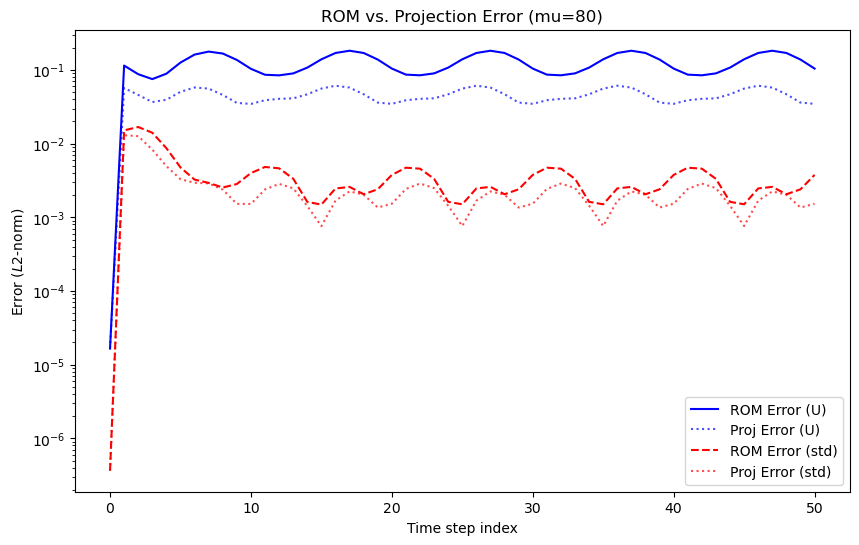

In [153]:
# now the same plot, but for L2 error

# compute both ROM errors
error_rom_U = (u_fom_test1 - u_rec_U).norm(fom.products['l2'])  # (Pr(u_h) - u_r)
error_rom_std = (u_fom_test1 - u_rec_std).norm(fom.products['l2'])  # (Pr(u_h) - u_r)

# for the error anylysis: (u_h - u_r) = (u_h - Pr(u_h)) + (Pr(u_h) - u_r))
# compute Pr(u_h), the projection of the FOM solution onto pod_basis (with r modes)

# for U
coeffs_U = fom.products['h1_0_semi'].apply2(U_pod_basis[:r], u_fom_test1) 
u_projected_U = U_pod_basis[:r].lincomb(coeffs_U)                       # proj onto U ROM
error_proj_U = (u_fom_test1 - u_projected_U).norm(fom.products['l2']) # (u_h - Pr(u_h))

# for std
coeffs_std = fom.products['h1_0_semi'].apply2(std_pod_basis[:r], u_fom_test1) 
u_projected_std = std_pod_basis[:r].lincomb(coeffs_std)              # proj onto std ROM
error_proj_std = (u_fom_test1 - u_projected_std).norm(fom.products['l2']) # (u_h - Pr(u_h)) max over time




plt.figure(figsize=(10, 6))
plt.semilogy(error_rom_U, 'b-', label='ROM Error (U)')
plt.semilogy(error_proj_U, 'b:', alpha=0.7, label='Proj Error (U)')
plt.semilogy(error_rom_std, 'r--', label='ROM Error (std)')
plt.semilogy(error_proj_std, 'r:', alpha=0.7, label='Proj Error (std)')
plt.xlabel('Time step index')
plt.ylabel(r'Error ($L2$-norm)')
plt.title(f'ROM vs. Projection Error (mu={test_mu})')
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

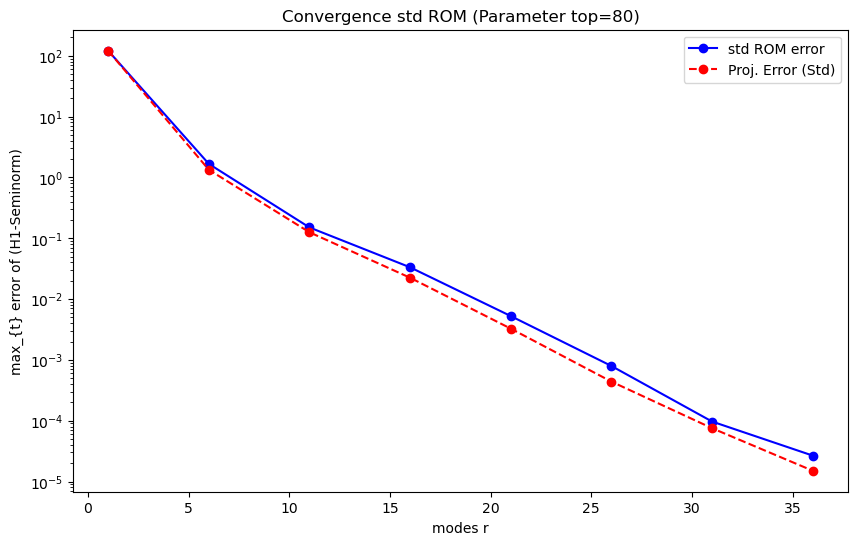

In [154]:
# now we consider differnt values for r and max over t, still one parameter

max_r = len(std_pod_basis)
r_values = range(1, max_r + 1, 5) 
errors_std = []
errors_proj_std = []

for r in r_values:

        #print(f"start{r}")
 
        rom_r_std = reductor_std.reduce(dims={'RB': r})  # construct ROM with r modes
        u_rom_std = rom_r_std.solve(test_mu) # solve for testmu
        u_rec_std = reductor_std.reconstruct(u_rom_std) # reconstruct to high dim
    
       
        err = np.max((u_fom_test1 - u_rec_std).norm(fom.h1_0_semi_product))   # consider error max{t}\norm{(u_h - u_r^std)}
        errors_std.append(err)

        # here also include the projection error
    
        # for std
        coeffs_std = fom.products['h1_0_semi'].apply2(std_pod_basis[:r], u_fom_test1) 
        u_projected_std = std_pod_basis[:r].lincomb(coeffs_std)              # proj onto std ROM
    
        error_proj_std_max = np.max((u_fom_test1 - u_projected_std).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        
        errors_proj_std.append(error_proj_std_max)

        
plt.figure(figsize=(10, 6))
plt.semilogy(r_values, errors_std, 'b-o', label='std ROM error')
plt.semilogy(r_values, errors_proj_std, 'r--o', label='Proj. Error (Std)')
plt.xlabel('modes r')
plt.ylabel('max_{t} error of (H1-Seminorm)')
plt.title(f'Convergence std ROM (Parameter top={test_mu})')
#plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

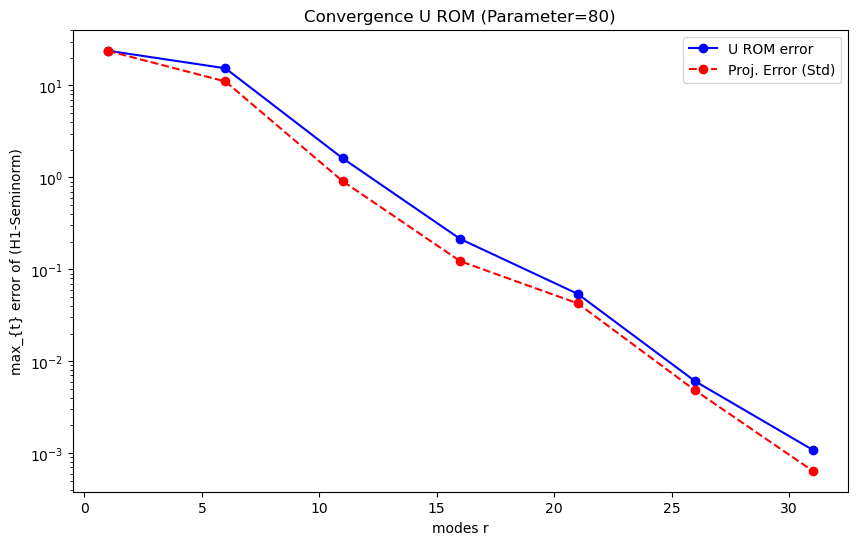

In [155]:
# schleife über r modes für U rom (immer 5 r höher), fehler dann max t und H01 norm, für einen festen parameter

max_r_U = len(U_pod_basis)
r_values_U = range(1, max_r_U + 1, 5)

errors_U = []
errors_proj_U = []

for r in r_values_U:

        #print(f"start{r}")

        rom_r_U = reductor_U.reduce(dims={'RB': r}) # construct ROM with r modes
        u_rom_U = rom_r_U.solve(test_mu) # solve for testmu
        u_rec_U = reductor_U.reconstruct(u_rom_U) # reconstruct to high dim
    
       
        err = np.max((u_fom_test1 - u_rec_U).norm(fom.h1_0_semi_product))   # consider error max{t}\norm{(u_h - u_r^std)}
        errors_U.append(err)


        # for U
        coeffs_U = fom.products['h1_0_semi'].apply2(U_pod_basis[:r], u_fom_test1) 
        u_projected_U = U_pod_basis[:r].lincomb(coeffs_U)              # proj onto U ROM
    
        error_proj_U_max = np.max((u_fom_test1 - u_projected_U).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        
        errors_proj_U.append(error_proj_U_max)

        

plt.figure(figsize=(10, 6))
plt.semilogy(r_values_U, errors_U, 'b-o', label='U ROM error')
plt.semilogy(r_values_U, errors_proj_U, 'r--o', label='Proj. Error (Std)')
plt.xlabel('modes r')
plt.ylabel('max_{t} error of (H1-Seminorm)')
plt.title(f'Convergence U ROM (Parameter={test_mu})')
#plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

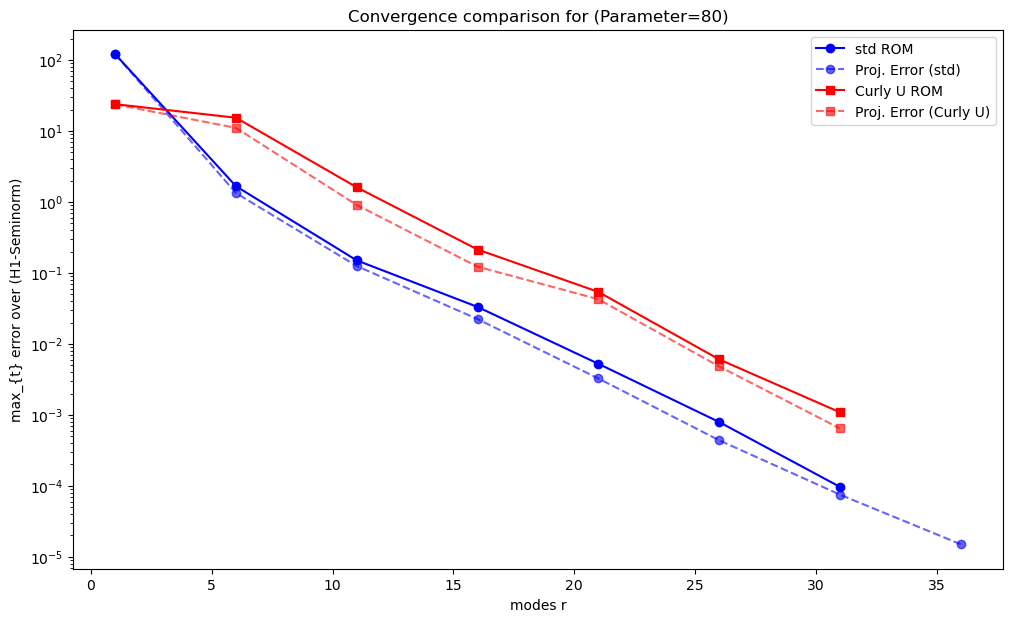

In [156]:
# now for both ROMs (including proj errors)

# passe Länge an
n_points = min(len(errors_std), len(errors_U))

plot_errors_std = errors_std[:n_points]
plot_errors_U = errors_U[:n_points]
plot_r_values = r_values[:n_points] 

plt.figure(figsize=(12,7))
plt.semilogy(plot_r_values, plot_errors_std, 'b-o', label='std ROM')
plt.semilogy(r_values, errors_proj_std, 'b--o', label='Proj. Error (std)', alpha=0.6)

plt.semilogy(plot_r_values, plot_errors_U, 'r-s', label='Curly U ROM')
plt.semilogy(r_values_U, errors_proj_U, 'r--s', label='Proj. Error (Curly U)', alpha=0.6)

plt.xlabel('modes r')
plt.ylabel('max_{t} error over (H1-Seminorm)')
plt.title(f'Convergence comparison for (Parameter={test_mu})')
#plt.grid(True, which="both", ls="--", alpha=0.5)
#plt.xticks(r_values)
plt.legend()
plt.show()

In [157]:
# now we need to fo this for several parameters 'top' and then consider min, max and average
# sp now we compute more fom solutions

number_of_test_mus = 35
test_mus = parameter_space.sample_uniformly(number_of_test_mus)

fom_solutions = []

for mu_idx, mu in enumerate(test_mus):  # loop over parameters (save index) 

    u_fom = fom.solve(mu) 
    fom_solutions.append(u_fom)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [ ]:
# std case 

max_r_std = len(std_pod_basis)
r_values_std = range(1, max_r_std + 1, 5)

all_errors_std = np.zeros((number_of_test_mus, len(r_values_std))) # to access min, max, average
errors_proj_std = []
all_errors_proj_std = np.zeros((number_of_test_mus, len(r_values_std)))

for mu_idx, mu in enumerate(test_mus):  # loop over parameters (save index) 
    #print(f"mu loop for {mu_idx+1}/{number_of_test_mus}: {mu['top'][0]}")
    
    for r_idx, r in enumerate(r_values_std):   # loop over modes 
        
        u_fom = fom_solutions[mu_idx]  # access fom solution
        
        rom_r_std = reductor_std.reduce(dims={'RB': r}) # construct ROM with r modes
        u_rom_std = rom_r_std.solve(mu)
        u_rec_std = reductor_std.reconstruct(u_rom_std) # reconstruct to high dim
        
        err = np.max((u_fom - u_rec_std).norm(fom.h1_0_semi_product))
        all_errors_std[mu_idx, r_idx] = err                       # add err to exactly this index

        # include the projection error
        coeffs_std = fom.products['h1_0_semi'].apply2(std_pod_basis[:r], u_fom) 
        u_projected_std = std_pod_basis[:r].lincomb(coeffs_std)              # proj onto std ROM
    
        error_proj_std_max = np.max((u_fom - u_projected_std).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        all_errors_proj_std[mu_idx, r_idx] = error_proj_std_max
       


min_err_std = np.min(all_errors_std, axis=0)  # take min over all parameters
max_err_std = np.max(all_errors_std, axis=0)
mean_err_std = np.mean(all_errors_std, axis=0)

min_err_std_proj = np.min(all_errors_proj_std, axis=0)  # take min over all parameters
max_err_std_proj = np.max(all_errors_proj_std, axis=0)
mean_err_std_proj = np.mean(all_errors_proj_std, axis=0)


#min_err_std, max_err_std, mean_err_std

In [ ]:
# plot std

plt.figure(figsize=(10, 6))
plt.fill_between(r_values_std, min_err_std, max_err_std, color='b', alpha=0.2)

plt.semilogy(r_values_std, mean_err_std, 'b-o', linewidth=2, label='mean error')
plt.semilogy(r_values_std, max_err_std, 'r-', alpha=0.7, label='max error')
plt.semilogy(r_values_std, min_err_std, 'g-', alpha=0.7, label='min error')

plt.semilogy(r_values_std, mean_err_std_proj, 'b--o', linewidth=2, label='mean error (proj)')
plt.semilogy(r_values_std, max_err_std_proj, 'r--', alpha=0.7, label='max error (proj)')
plt.semilogy(r_values_std, min_err_std_proj, 'g--', alpha=0.7, label='min error(proj)')

plt.xlabel('modes r')
plt.ylabel('ROM error in (H1-Seminorm), max over t')
plt.title(f'Std ROM over {number_of_test_mus} Parameter')
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [ ]:
# U case 

max_r_U = len(U_pod_basis)
r_values_U = range(1, max_r_U + 1, 5)

all_errors_U = np.zeros((number_of_test_mus, len(r_values_U))) # to access min, max, average
errors_proj_U = []
all_errors_proj_U = np.zeros((number_of_test_mus, len(r_values_U)))

for mu_idx, mu in enumerate(test_mus):  # loop over parameters (save index) 
    #print(f"mu loop for {mu_idx+1}/{number_of_test_mus}: {mu['top'][0]}")
    
    for r_idx, r in enumerate(r_values_U):   # loop over modes 
        
        u_fom = fom_solutions[mu_idx]  # access fom solution
        
        rom_r_U = reductor_U.reduce(dims={'RB': r}) # construct ROM with r modes
        u_rom_U = rom_r_U.solve(mu) 
        u_rec_U = reductor_U.reconstruct(u_rom_U) # reconstruct to high dim
        
        err = np.max((u_fom - u_rec_U).norm(fom.h1_0_semi_product))
        all_errors_U[mu_idx, r_idx] = err                       # add err to exactly this index


        # include the projection error
        coeffs_U = fom.products['h1_0_semi'].apply2(U_pod_basis[:r], u_fom) 
        u_projected_U = U_pod_basis[:r].lincomb(coeffs_U)              # proj onto std ROM
    
        error_proj_U_max = np.max((u_fom - u_projected_U).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        all_errors_proj_U[mu_idx, r_idx] = error_proj_U_max
       


min_err_U = np.min(all_errors_U, axis=0)  # take min over all parameters
max_err_U = np.max(all_errors_U, axis=0)
mean_err_U = np.mean(all_errors_U, axis=0)

min_err_U_proj = np.min(all_errors_proj_U, axis=0)  # take min over all parameters
max_err_U_proj = np.max(all_errors_proj_U, axis=0)
mean_err_U_proj = np.mean(all_errors_proj_U, axis=0)


#min_err_U, max_err_U, mean_err_U

In [ ]:
# plot U

plt.figure(figsize=(10, 6))
plt.fill_between(r_values_U, min_err_U, max_err_U, color='b', alpha=0.2)

plt.semilogy(r_values_U, mean_err_U, 'b-o', linewidth=2, label='mean error')
plt.semilogy(r_values_U, max_err_U, 'r-', alpha=0.7, label='max error')
plt.semilogy(r_values_U, min_err_U, 'g-', alpha=0.7, label='min error')

plt.semilogy(r_values_U, mean_err_U_proj, 'b--o', linewidth=2, label='mean error (proj)')
plt.semilogy(r_values_U, max_err_U_proj, 'r--', alpha=0.7, label='max error (proj)')
plt.semilogy(r_values_U, min_err_U_proj, 'g--', alpha=0.7, label='min error(proj)')


plt.xlabel('modes r')
plt.ylabel('ROM error in (H1-Seminorm), max over t')
plt.title(f'U ROM over {number_of_test_mus} Parameter')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [ ]:

n = min(len(r_values_U), len(r_values_std))
r_plot = r_values_U[:n] if len(r_values_U) <= len(r_values_std) else r_values_std[:n]

plt.figure(figsize=(10, 6))


plt.fill_between(r_plot, min_err_U[:n], max_err_U[:n], color='b', alpha=0.15)
plt.semilogy(r_plot, mean_err_U[:n], 'b-o', linewidth=2, label='mean error (U)')
plt.semilogy(r_plot, max_err_U[:n], 'b--', alpha=0.5)
plt.semilogy(r_plot, min_err_U[:n], 'b:', alpha=0.5)

plt.fill_between(r_plot, min_err_std[:n], max_err_std[:n], color='r', alpha=0.15)
plt.semilogy(r_plot, mean_err_std[:n], 'r-s', linewidth=2, label='mean error (std)')
plt.semilogy(r_plot, max_err_std[:n], 'r--', alpha=0.5)
plt.semilogy(r_plot, min_err_std[:n], 'r:', alpha=0.5)

plt.xlabel('modes r')
plt.ylabel(r'ROM error ($H^1$-Seminorm), max over t')
plt.title(f'Comparison: mean, min, max over {number_of_test_mus} Parameters')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# 255 snapshots(5*50)
# durchschnitt über viele Parameter (und min und max)
# max über Zeit
# H01 seminorm
# ansteigende modes r
# für beide ROM methoden

In [ ]:
# L2
# std case 

max_r_std = len(std_pod_basis)
r_values_std = range(1, max_r_std + 1, 5)

all_errors_std = np.zeros((number_of_test_mus, len(r_values_std))) # to access min, max, average


for mu_idx, mu in enumerate(test_mus):  # loop over parameters (save index) 
    #print(f"mu loop for {mu_idx+1}/{number_of_test_mus}: {mu['top'][0]}")
    
    for r_idx, r in enumerate(r_values_std):   # loop over modes 
        
        u_fom = fom_solutions[mu_idx]  # access fom solution
        
        rom_r_std = reductor_std.reduce(dims={'RB': r}) # construct ROM with r modes
        u_rom_std = rom_r_std.solve(mu)
        u_rec_std = reductor_std.reconstruct(u_rom_std) # reconstruct to high dim
        
        err = np.max((u_fom - u_rec_std).norm(fom.l2_product))
        all_errors_std[mu_idx, r_idx] = err                       # add err to exactly this index


min_err_std = np.min(all_errors_std, axis=0)  # take min over all parameters
max_err_std = np.max(all_errors_std, axis=0)
mean_err_std = np.mean(all_errors_std, axis=0)

#min_err_std, max_err_std, mean_err_std

In [ ]:
# L2
# U case 

max_r_U = len(U_pod_basis)
r_values_U = range(1, max_r_U + 1, 5)

all_errors_U = np.zeros((number_of_test_mus, len(r_values_U))) # to access min, max, average


for mu_idx, mu in enumerate(test_mus):  # loop over parameters (save index) 
    #print(f"mu loop for {mu_idx+1}/{number_of_test_mus}: {mu['top'][0]}")
    
    for r_idx, r in enumerate(r_values_U):   # loop over modes 
        
        u_fom = fom_solutions[mu_idx]  # access fom solution
        
        rom_r_U = reductor_U.reduce(dims={'RB': r}) # construct ROM with r modes
        u_rom_U = rom_r_U.solve(mu) 
        u_rec_U = reductor_U.reconstruct(u_rom_U) # reconstruct to high dim
        
        err = np.max((u_fom - u_rec_U).norm(fom.l2_product))
        all_errors_U[mu_idx, r_idx] = err                       # add err to exactly this index


min_err_U = np.min(all_errors_U, axis=0)  # take min over all parameters
max_err_U = np.max(all_errors_U, axis=0)
mean_err_U = np.mean(all_errors_U, axis=0)

#min_err_U, max_err_U, mean_err_U

In [ ]:
n = min(len(r_values_U), len(r_values_std))
r_plot = r_values_U[:n] if len(r_values_U) <= len(r_values_std) else r_values_std[:n]

plt.figure(figsize=(10, 6))


plt.fill_between(r_plot, min_err_U[:n], max_err_U[:n], color='b', alpha=0.15)
plt.semilogy(r_plot, mean_err_U[:n], 'b-o', linewidth=2, label='mean error (U)')
plt.semilogy(r_plot, max_err_U[:n], 'b--', alpha=0.5)
plt.semilogy(r_plot, min_err_U[:n], 'b:', alpha=0.5)

plt.fill_between(r_plot, min_err_std[:n], max_err_std[:n], color='r', alpha=0.15)
plt.semilogy(r_plot, mean_err_std[:n], 'r-s', linewidth=2, label='mean error (std)')
plt.semilogy(r_plot, max_err_std[:n], 'r--', alpha=0.5)
plt.semilogy(r_plot, min_err_std[:n], 'r:', alpha=0.5)

plt.xlabel('modes r')
plt.ylabel(r'ROM error ($L2$-Seminorm), max over t')
plt.title(f'Comparison: mean, min, max over {number_of_test_mus} Parameters')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()


# durchschnitt über viele Parameter (und min und max)
# max über Zeit
# L2 seminorm
# ansteigende modes r
# für beide ROM methoden